### Setup base model and data

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LinearRegression

device = 'cuda' if torch.cuda.is_available() else 'cpu'


np.random.seed(0)
n_train, n_calib = 100, 100
X = np.random.uniform(-5, 5, size=(n_train + n_calib, 1))
y = 2 * X.squeeze() + np.random.normal(0, 1.5, size=(n_train + n_calib))

X_train, y_train = X[:n_train], y[:n_train]
X_calib, y_calib = X[n_train:], y[n_train:]

model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_calib, y_calib)

0.9289240922482948

### Train Neural Network (Policy Learner)

In [13]:

class AlphaNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.initialize_to_one()

    def initialize_to_one(self):
        with torch.no_grad():
            self.fc2.weight.data.normal_(0, 0.01)
            self.fc2.bias.data.fill_(5.0)  

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.sigmoid(self.fc2(x)).squeeze(-1)

def interval_size(scores, alpha):
    """
    scores: tensor of shape (n,) -> S(X_j, Y_j)
    alpha: scalar
    returns: 2*r, the size of the conformal interval
    """
    n = len(scores)
    r = scores.sum() / (alpha * (n + 1) - 1)
    return 2 * r


train_inputs = []
n_calib = len(X_calib)

for i in range(n_calib):
    loo_X = np.delete(X_calib, i, axis=0)
    loo_y = np.delete(y_calib, i, axis=0)
    scores = np.abs(model.predict(loo_X) - loo_y)

    input_feat = torch.tensor([scores.sum()], dtype=torch.float32)
    train_inputs.append(input_feat)

X_train_alpha = torch.stack(train_inputs) 


def train_alpha_net(lambda_reg, run_id=0, num_epochs=50, batch_size=32):
    train_dataset = TensorDataset(X_train_alpha, torch.arange(len(X_train_alpha)))  
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    alpha_net = AlphaNet(input_dim=1).to(device)
    optimizer = optim.Adam(alpha_net.parameters(), lr=1e-3)

    all_losses, all_sizes, all_alphas = [], [], []

    for epoch in range(num_epochs):
        total_loss = 0
        total_size = 0
        total_alpha = 0

        for x_batch, idx_batch in train_loader:
            x_batch = x_batch.to(device)
            alpha_pred = alpha_net(x_batch)

            batch_sizes = []
            for j, idx in enumerate(idx_batch):
                loo_X = np.delete(X_calib, idx.item(), axis=0)
                loo_y = np.delete(y_calib, idx.item(), axis=0)
                scores = torch.tensor(np.abs(model.predict(loo_X) - loo_y), dtype=torch.float32).to(device)
                size_j = interval_size(scores, alpha_pred[j])
                batch_sizes.append(size_j)

            batch_sizes = torch.stack(batch_sizes)
            loss = (batch_sizes + lambda_reg * alpha_pred).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_size += batch_sizes.mean().item()
            total_alpha += alpha_pred.mean().item()

        all_losses.append(total_loss / len(train_loader))
        all_sizes.append(total_size / len(train_loader))
        all_alphas.append(total_alpha / len(train_loader))

        if epoch % 5 == 0 or epoch == num_epochs-1:
            print(f"Lambda {lambda_reg} | Run {run_id+1} | Epoch {epoch}/{num_epochs} | "
                  f"Loss: {all_losses[-1]:.4f} | Mean Size: {all_sizes[-1]:.4f} | Mean Alpha: {all_alphas[-1]:.4f}")

    return np.array(all_losses), np.array(all_sizes), np.array(all_alphas), alpha_net

lambdas = [10, 20, 30]
num_runs = 4
all_results = {}

for lam in lambdas:
    losses_runs = []
    sizes_runs = []
    alphas_runs = []
    nets_runs = []                                 
    for run in range(num_runs):
        np.random.seed(run)
        torch.manual_seed(run)
        print(f"\nStarting Lambda {lam} | Run {run+1}/{num_runs}")
        losses, sizes, alphas, alpha_net = train_alpha_net(lambda_reg=lam, run_id=run)
        losses_runs.append(losses)
        sizes_runs.append(sizes)
        alphas_runs.append(alphas)
        nets_runs.append(alpha_net)                 
    all_results[lam] = {
        'losses': np.array(losses_runs),
        'sizes': np.array(sizes_runs),
        'alphas': np.array(alphas_runs),
        'nets': nets_runs,                          
    }



Starting Lambda 10 | Run 1/4
Lambda 10 | Run 1 | Epoch 0/50 | Loss: 11.8164 | Mean Size: 2.5399 | Mean Alpha: 0.9276
Lambda 10 | Run 1 | Epoch 5/50 | Loss: 9.8013 | Mean Size: 5.2330 | Mean Alpha: 0.4568
Lambda 10 | Run 1 | Epoch 10/50 | Loss: 9.7505 | Mean Size: 4.8577 | Mean Alpha: 0.4893
Lambda 10 | Run 1 | Epoch 15/50 | Loss: 9.7398 | Mean Size: 4.7070 | Mean Alpha: 0.5033
Lambda 10 | Run 1 | Epoch 20/50 | Loss: 9.7389 | Mean Size: 4.8098 | Mean Alpha: 0.4929
Lambda 10 | Run 1 | Epoch 25/50 | Loss: 9.7411 | Mean Size: 4.8686 | Mean Alpha: 0.4872
Lambda 10 | Run 1 | Epoch 30/50 | Loss: 9.7372 | Mean Size: 4.8322 | Mean Alpha: 0.4905
Lambda 10 | Run 1 | Epoch 35/50 | Loss: 9.7409 | Mean Size: 4.8062 | Mean Alpha: 0.4935
Lambda 10 | Run 1 | Epoch 40/50 | Loss: 9.7383 | Mean Size: 4.7943 | Mean Alpha: 0.4944
Lambda 10 | Run 1 | Epoch 45/50 | Loss: 9.7425 | Mean Size: 4.8560 | Mean Alpha: 0.4887
Lambda 10 | Run 1 | Epoch 49/50 | Loss: 9.7389 | Mean Size: 4.8556 | Mean Alpha: 0.4883

St

In [14]:
# evaluate model training
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import AutoMinorLocator
from tueplots import bundles

os.makedirs("plots", exist_ok=True)

all_losses_10 = all_results[10]['losses']
all_sizes_10 = all_results[10]['sizes']
all_alphas_10 = all_results[10]['alphas']

all_losses_20 = all_results[20]['losses']
all_sizes_20 = all_results[20]['sizes']
all_alphas_20 = all_results[20]['alphas']

all_losses_50 = all_results[50]['losses']
all_sizes_50 = all_results[50]['sizes']
all_alphas_50 = all_results[50]['alphas']

def moving_average(arr, window_size):
    return np.convolve(arr, np.ones(window_size)/window_size, mode='valid')

def smooth_all(arr_2d, window):
    smoothed_runs = []
    for run in arr_2d:
        smoothed = moving_average(run, window)
        smoothed_runs.append(smoothed)
    smoothed_runs = np.array(smoothed_runs)
    mean = np.nanmean(smoothed_runs, axis=0)
    std = np.nanstd(smoothed_runs, axis=0)
    return mean, std

window_size = 10

mean_loss_10, std_loss_10 = smooth_all(all_losses_10, window_size)
mean_loss_20, std_loss_20 = smooth_all(all_losses_20, window_size)
mean_loss_50, std_loss_50 = smooth_all(all_losses_50, window_size)

mean_size_10, std_size_10 = smooth_all(all_sizes_10, window_size)
mean_size_20, std_size_20 = smooth_all(all_sizes_20, window_size)
mean_size_50, std_size_50 = smooth_all(all_sizes_50, window_size)

mean_alpha_10, std_alpha_10 = smooth_all(all_alphas_10, window_size)
mean_alpha_20, std_alpha_20 = smooth_all(all_alphas_20, window_size)
mean_alpha_50, std_alpha_50 = smooth_all(all_alphas_50, window_size)

epochs = np.arange(1, all_losses_10.shape[1] + 1)
epochs_smoothed = epochs[:len(mean_loss_10)]

plt.rcParams.update(bundles.icml2024())
plt.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2,
    "axes.linewidth": 2,
    "text.usetex": False,
})

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

color_10 = "#0077bb"
color_20 = "#cc3311"
color_50 = "#44aa99"

# plot loss
axs[0].plot(epochs_smoothed, mean_loss_10, label=r'$\lambda=10$', color=color_10)
axs[0].fill_between(epochs_smoothed, mean_loss_10-std_loss_10, mean_loss_10+std_loss_10, color=color_10, alpha=0.3)

axs[0].plot(epochs_smoothed, mean_loss_20, label=r'$\lambda=20$', color=color_20)
axs[0].fill_between(epochs_smoothed, mean_loss_20-std_loss_20, mean_loss_20+std_loss_20, color=color_20, alpha=0.3)

axs[0].plot(epochs_smoothed, mean_loss_50, label=r'$\lambda=50$', color=color_50)
axs[0].fill_between(epochs_smoothed, mean_loss_50-std_loss_50, mean_loss_50+std_loss_50, color=color_50, alpha=0.3)

axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("Training Loss")
axs[0].grid(True)

# plot mean size
axs[1].plot(epochs_smoothed, mean_size_10, label=r'$\lambda=10$', color=color_10)
axs[1].fill_between(epochs_smoothed, mean_size_10-std_size_10, mean_size_10+std_size_10, color=color_10, alpha=0.3)

axs[1].plot(epochs_smoothed, mean_size_20, label=r'$\lambda=20$', color=color_20)
axs[1].fill_between(epochs_smoothed, mean_size_20-std_size_20, mean_size_20+std_size_20, color=color_20, alpha=0.3)

axs[1].plot(epochs_smoothed, mean_size_50, label=r'$\lambda=50$', color=color_50)
axs[1].fill_between(epochs_smoothed, mean_size_50-std_size_50, mean_size_50+std_size_50, color=color_50, alpha=0.3)

axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Mean Size")
axs[1].set_title("Mean Size per Epoch")
axs[1].grid(True)

# plot mean miscoverage
axs[2].plot(epochs_smoothed, mean_alpha_10, label=r'$\lambda=10$', color=color_10)
axs[2].fill_between(epochs_smoothed, mean_alpha_10-std_alpha_10, mean_alpha_10+std_alpha_10, color=color_10, alpha=0.3)

axs[2].plot(epochs_smoothed, mean_alpha_20, label=r'$\lambda=20$', color=color_20)
axs[2].fill_between(epochs_smoothed, mean_alpha_20-std_alpha_20, mean_alpha_20+std_alpha_20, color=color_20, alpha=0.3)

axs[2].plot(epochs_smoothed, mean_alpha_50, label=r'$\lambda=50$', color=color_50)
axs[2].fill_between(epochs_smoothed, mean_alpha_50-std_alpha_50, mean_alpha_50+std_alpha_50, color=color_50, alpha=0.3)

axs[2].set_xlabel("Epoch")
axs[2].set_ylabel(r"Mean $\tilde\alpha$")
axs[2].set_title(r"Mean $\tilde\alpha$ per Epoch")
axs[2].grid(True)
axs[2].legend(frameon=True)

for ax in axs:
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='both', length=4)
    ax.tick_params(which='minor', length=2, width=1.5)
    ax.tick_params(which='major', width=2)

plt.tight_layout()
plt.savefig("plots/training.pdf", format="pdf", bbox_inches="tight")
plt.show()


KeyError: 50

C:\Users\User\AppData\Local\Temp\ipykernel_15724\3508712183.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


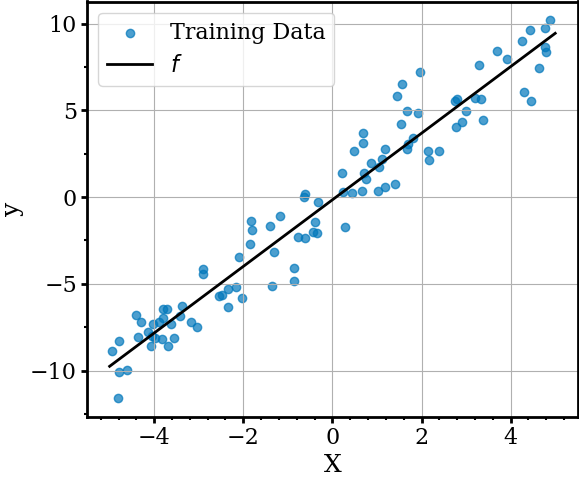

In [9]:
import matplotlib.pyplot as plt
from tueplots import bundles
from matplotlib.ticker import AutoMinorLocator

plt.rcParams.update(bundles.icml2024())
plt.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2,
    "axes.linewidth": 2,
    "text.usetex": False,
})

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(X_train, y_train, color="#0077bb", alpha=0.7, label="Training Data")

x_line = np.linspace(-5, 5, 200).reshape(-1, 1)
y_pred_line = model.predict(x_line)
ax.plot(x_line, y_pred_line, color="black", linewidth=2, label=r"$f$")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.legend(frameon=True)
ax.grid(True)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='both', length=4)
ax.tick_params(which='minor', length=2, width=1.5)
ax.tick_params(which='major', width=2)

plt.tight_layout()
plt.savefig("plots/data.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
alpha_net.eval()
scores_calib = np.abs(model.predict(X_calib) - y_calib)
sum_scores = scores_calib.sum()

np.random.seed(123)
X_test = np.random.uniform(-5, 5, size=(2000, 1))
y_test = 2 * X_test.squeeze() + np.random.normal(0, 1, size=2000)

feat = torch.tensor([sum_scores], dtype=torch.float32).to(device)
alpha_val = alpha_net(feat).item()

size = interval_size(torch.tensor(scores_calib, dtype=torch.float32), alpha_val)

print("Mean conformal set size:", size)


Mean conformal set size: tensor(11.8253)


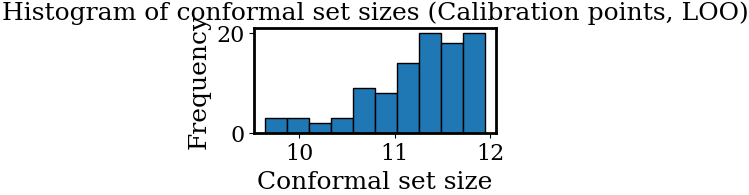

Mean conformal set size (calibration, LOO): 11.242154


In [ ]:

sizes_calib = []
n_calib = len(X_calib)

for i in range(n_calib):
    loo_X = np.delete(X_calib, i, axis=0)
    loo_y = np.delete(y_calib, i, axis=0)
    scores_loo = np.abs(model.predict(loo_X) - loo_y)

    feat_i = torch.tensor([scores_loo.sum()], dtype=torch.float32).to(device)
    alpha_val = alpha_net(feat_i).item()

    size_i = interval_size(torch.tensor(scores_loo, dtype=torch.float32), alpha_val)
    sizes_calib.append(size_i)


import matplotlib.pyplot as plt

plt.hist(sizes_calib, bins=10, edgecolor='k')
plt.xlabel("Conformal set size")
plt.ylabel("Frequency")
plt.title("Histogram of conformal set sizes (Calibration points, LOO)")
plt.show()

print("Mean conformal set size (calibration, LOO):", np.mean(sizes_calib))


## 11. Closed-form optimal coverage policy

With the MAE score $S(x,y)=|f(x)-y|$ the soft-rank e-value conformal set is an interval of size

$$\mathrm{Size}(\alpha)=\frac{2\Sigma}{(n+1)\alpha-1},\qquad \Sigma:=\sum_{i=1}^{n}S(X_i,Y_i),\qquad \alpha>\tfrac{1}{n+1}$$

so the training objective $L(\alpha)=\mathrm{Size}(\alpha)+\lambda\alpha$ is smooth and strictly convex. 

Setting $L'(\alpha)=0$:

$$\boxed{\;\alpha^\star(\Sigma)=\frac{1+\sqrt{2\Sigma(n+1)/\lambda}}{n+1}\;,\qquad \mathrm{Size}^\star=\sqrt{\frac{2\Sigma\lambda}{n+1}}\;,\qquad r^\star=\tfrac12\mathrm{Size}^\star\;}$$


In [15]:
# closed-form minimiser of L(alpha) = Size(alpha) + lambda * alpha

def alpha_star(Sigma, n, lam):
    return (1.0 + np.sqrt(2.0 * Sigma * (n + 1) / lam)) / (n + 1)

def size_star(Sigma, n, lam):
    return np.sqrt(2.0 * Sigma * lam / (n + 1))

def size_of_alpha(Sigma, n, alpha):
    """Conformal interval size at an arbitrary alpha."""
    return 2.0 * Sigma / ((n + 1) * np.asarray(alpha, dtype=float) - 1.0)

n_calib = len(X_calib)
n_loo = n_calib - 1              

loo_sums = np.empty(n_calib)
loo_resid = np.empty(n_calib)
for i in range(n_calib):
    loo_X = np.delete(X_calib, i, axis=0)
    loo_y = np.delete(y_calib, i, axis=0)
    loo_sums[i] = np.abs(model.predict(loo_X) - loo_y).sum()
    loo_resid[i] = np.abs(model.predict(X_calib[i:i+1])[0] - y_calib[i])

def evaluate_policy(alphas, sums=loo_sums, resid=loo_resid, n=n_loo):
    """alphas: per-episode miscoverage level.
    Returns (mean alpha, mean window size, empirical miscoverage)."""
    alphas = np.asarray(alphas, dtype=float)
    sizes = size_of_alpha(sums, n, alphas)
    radii = sizes / 2.0
    miscov = float(np.mean(resid > radii))
    return float(alphas.mean()), float(sizes.mean()), miscov

def learned_alphas(net, sums=loo_sums):
    net.eval()
    with torch.no_grad():
        feats = torch.tensor(sums.reshape(-1, 1), dtype=torch.float32).to(device)
        return net(feats).cpu().numpy().reshape(-1)

comparison = {}

print(f"Calibration set: n_calib = {n_calib}   (LOO episodes use n = {n_loo})")
print(f"Sigma over LOO episodes: mean {loo_sums.mean():.3f}, "
      f"range [{loo_sums.min():.3f}, {loo_sums.max():.3f}]\n")

header = f"{'lambda':>7} {'policy':>12} {'mean alpha':>12} {'mean size':>11} {'emp. miscov':>12} {'loss':>9}"
print(header)
print("-" * len(header))

for lam in lambdas:
    # ---- closed form ----
    a_cf = alpha_star(loo_sums, n_loo, lam)
    m_a_cf, m_s_cf, mis_cf = evaluate_policy(a_cf)
    loss_cf = m_s_cf + lam * m_a_cf

    # ---- learned ----
    a_nn_runs = np.stack([learned_alphas(net) for net in all_results[lam]['nets']])
    stats_nn = np.array([evaluate_policy(a) for a in a_nn_runs])   # (runs, 3)
    m_a_nn, m_s_nn, mis_nn = stats_nn.mean(axis=0)
    sd_a_nn, sd_s_nn, sd_mis_nn = stats_nn.std(axis=0)
    loss_nn = m_s_nn + lam * m_a_nn

    print(f"{lam:>7} {'closed form':>12} {m_a_cf:>12.4f} {m_s_cf:>11.4f} {mis_cf:>12.3f} {loss_cf:>9.4f}")
    print(f"{'':>7} {'learned':>12} {m_a_nn:>12.4f} {m_s_nn:>11.4f} {mis_nn:>12.3f} {loss_nn:>9.4f}")
    print(f"{'':>7} {'(+/- sd)':>12} {sd_a_nn:>12.4f} {sd_s_nn:>11.4f} {sd_mis_nn:>12.3f} "
          f"{'gap: ' + format(loss_nn - loss_cf, '+.4f'):>9}")
    print()

    comparison[lam] = dict(
        a_cf=a_cf, m_a_cf=m_a_cf, m_s_cf=m_s_cf, mis_cf=mis_cf, loss_cf=loss_cf,
        a_nn_runs=a_nn_runs, m_a_nn=m_a_nn, m_s_nn=m_s_nn, mis_nn=mis_nn, loss_nn=loss_nn,
        sd_a_nn=sd_a_nn, sd_s_nn=sd_s_nn, sd_mis_nn=sd_mis_nn,
    )



Calibration set: n_calib = 100   (LOO episodes use n = 99)
Sigma over LOO episodes: mean 116.065, range [113.153, 117.227]

 lambda       policy   mean alpha   mean size  emp. miscov      loss
--------------------------------------------------------------------
     10  closed form       0.4918      4.8180        0.110    9.7359
             learned       0.4980      4.7597        0.115    9.7398
            (+/- sd)       0.0042      0.0410        0.005 gap: +0.0039

     20  closed form       0.3507      6.8136        0.040   13.8272
             learned       0.3495      6.8452        0.057   13.8356
            (+/- sd)       0.0032      0.0636        0.004 gap: +0.0084

     30  closed form       0.2882      8.3449        0.000   16.9899
             learned       0.2849      8.4589        0.010   17.0047
            (+/- sd)       0.0032      0.0969        0.000 gap: +0.0148



In [16]:
# repeat with new data
np.random.seed(123)
X_test = np.random.uniform(-5, 5, size=(2000, 1))
y_test = 2 * X_test.squeeze() + np.random.normal(0, 1, size=2000)

Sigma_full = np.abs(model.predict(X_calib) - y_calib).sum()
resid_test = np.abs(model.predict(X_test) - y_test)

print(f"Test set: {len(X_test)} points | Sigma (full calibration, n={n_calib}) = {Sigma_full:.3f}\n")

header = f"{'lambda':>7} {'policy':>12} {'alpha':>10} {'window size':>13} {'emp. miscov':>12} {'loss':>9}"
print(header)
print("-" * len(header))

test_results = {}
for lam in lambdas:
    a_cf = float(alpha_star(Sigma_full, n_calib, lam))
    s_cf = float(size_of_alpha(Sigma_full, n_calib, a_cf))
    mis_cf = float(np.mean(resid_test > s_cf / 2))

    a_nn_r, s_nn_r, mis_nn_r = [], [], []
    for net in all_results[lam]['nets']:
        net.eval()
        with torch.no_grad():
            a = float(net(torch.tensor([[Sigma_full]], dtype=torch.float32).to(device)).item())
        s = float(size_of_alpha(Sigma_full, n_calib, a))
        a_nn_r.append(a); s_nn_r.append(s)
        mis_nn_r.append(float(np.mean(resid_test > s / 2)))

    a_nn, s_nn, mis_nn = np.mean(a_nn_r), np.mean(s_nn_r), np.mean(mis_nn_r)

    print(f"{lam:>7} {'closed form':>12} {a_cf:>10.4f} {s_cf:>13.4f} {mis_cf:>12.3f} {s_cf + lam*a_cf:>9.4f}")
    print(f"{'':>7} {'learned':>12} {a_nn:>10.4f} {s_nn:>13.4f} {mis_nn:>12.3f} {s_nn + lam*a_nn:>9.4f}")
    print()

    test_results[lam] = dict(a_cf=a_cf, s_cf=s_cf, mis_cf=mis_cf,
                             a_nn=a_nn, s_nn=s_nn, mis_nn=mis_nn)

print("Sanity check: closed-form size* formula vs. numeric evaluation")
for lam in lambdas:
    print(f"  lambda={lam:>3}: sqrt(2*Sigma*lam/(n+1)) = {size_star(Sigma_full, n_calib, lam):.6f} "
          f"| Size(alpha*) = {test_results[lam]['s_cf']:.6f}")


Test set: 2000 points | Sigma (full calibration, n=100) = 117.238

 lambda       policy      alpha   window size  emp. miscov      loss
--------------------------------------------------------------------
     10  closed form     0.4917        4.8182        0.017    9.7355
             learned     0.4854        4.8824        0.015    9.7367

     20  closed form     0.3506        6.8140        0.001   13.8260
             learned     0.3367        7.1043        0.001   13.8385

     30  closed form     0.2881        8.3454        0.000   16.9879
             learned     0.2728        8.8322        0.000   17.0158

Sanity check: closed-form size* formula vs. numeric evaluation
  lambda= 10: sqrt(2*Sigma*lam/(n+1)) = 4.818231 | Size(alpha*) = 4.818231
  lambda= 20: sqrt(2*Sigma*lam/(n+1)) = 6.814008 | Size(alpha*) = 6.814008
  lambda= 30: sqrt(2*Sigma*lam/(n+1)) = 8.345421 | Size(alpha*) = 8.345421


C:\Users\User\AppData\Local\Temp\ipykernel_15724\3422437492.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


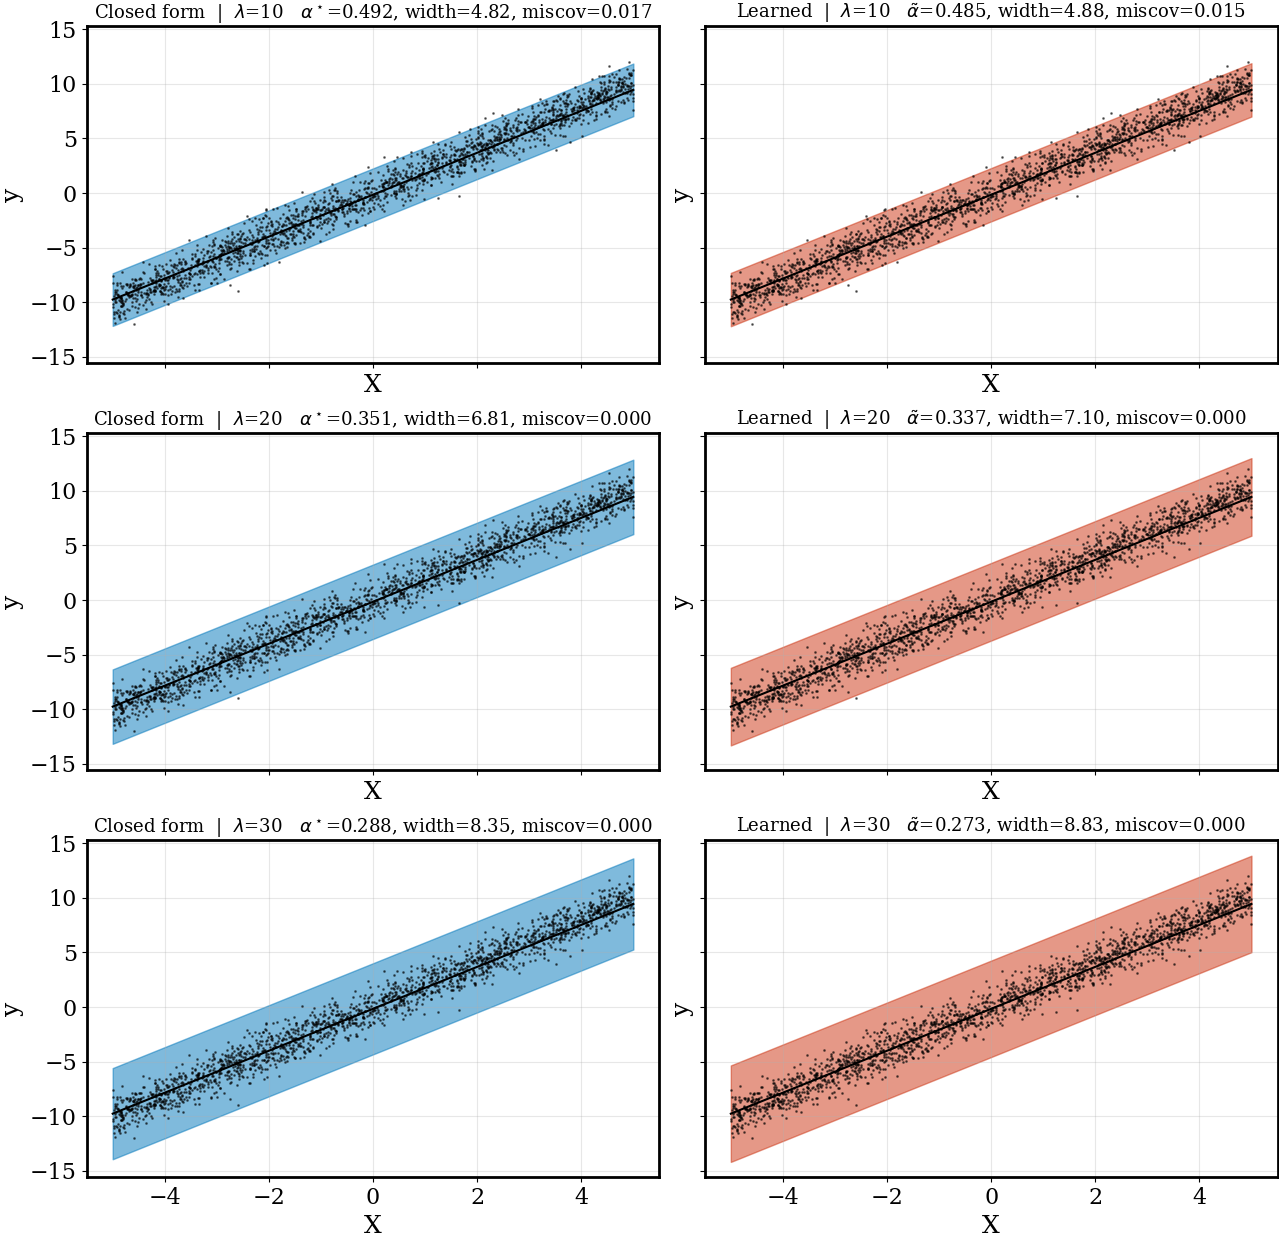

C:\Users\User\AppData\Local\Temp\ipykernel_15724\3422437492.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.93])   # reserve the top 7% for the suptitle


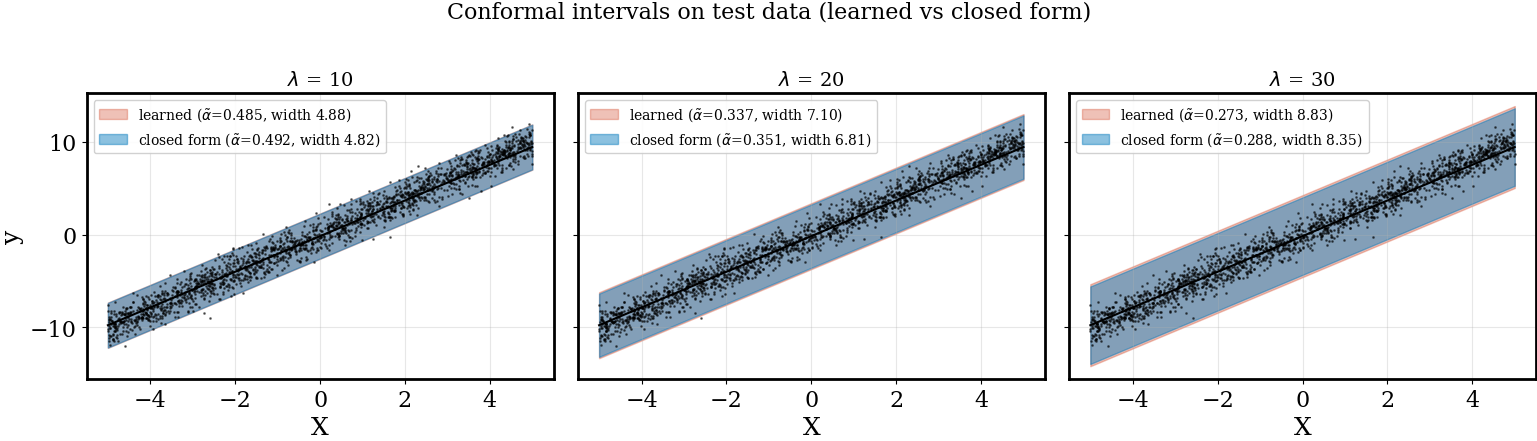

In [19]:
# visual comparison of the two intervals on the test data
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"text.usetex": False})

n_calib    = len(X_calib)
Sigma_full = np.abs(model.predict(X_calib) - y_calib).sum()

np.random.seed(123)
X_test = np.random.uniform(-5, 5, size=(2000, 1))
y_test = 2 * X_test.squeeze() + np.random.normal(0, 1, size=2000)
resid_test = np.abs(model.predict(X_test) - y_test)

X_grid = np.linspace(-5, 5, 400).reshape(-1, 1)
f_grid = model.predict(X_grid)

def _alpha_star(Sigma, n, lam):
    return (1.0 + np.sqrt(2.0 * Sigma * (n + 1) / lam)) / (n + 1)

def _radius(alpha):
    return Sigma_full / ((n_calib + 1) * float(alpha) - 1.0)

def _grid_from_alpha(alpha):
    r = _radius(alpha)
    return np.column_stack([f_grid - r, f_grid + r]), r

def _learned_alpha(lam):
    feat = torch.tensor([[Sigma_full]], dtype=torch.float32).to(device)
    vals = []
    for net in all_results[lam]['nets']:
        net.eval()
        with torch.no_grad():
            vals.append(float(net(feat).item()))
    return float(np.mean(vals))

def plot_interval(ax, grid, y_t, X_t, color, title):
    ax.fill_between(X_grid.flatten(), grid[:, 0], grid[:, 1], color=color, alpha=0.5)
    ax.plot(X_t.flatten(), y_t, 'k.', markersize=2, alpha=0.5)
    ax.plot(X_grid.flatten(), f_grid, color='k', lw=1.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("X"); ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)

fig, axs = plt.subplots(len(lambdas), 2, figsize=(13, 4.2 * len(lambdas)),
                        sharex=True, sharey=True)
axs = np.atleast_2d(axs)

for row, lam in enumerate(lambdas):
    a_cf = float(_alpha_star(Sigma_full, n_calib, lam))
    a_nn = _learned_alpha(lam)

    g_cf, r_cf = _grid_from_alpha(a_cf)
    g_nn, r_nn = _grid_from_alpha(a_nn)

    cov_cf = float(np.mean(resid_test <= r_cf))
    cov_nn = float(np.mean(resid_test <= r_nn))

    plot_interval(axs[row, 0], g_cf, y_test, X_test, "#0077bb",
                  f"Closed form  |  $\\lambda$={lam}   "
                  f"$\\alpha^\\star$={a_cf:.3f}, width={2*r_cf:.2f}, miscov={1-cov_cf:.3f}")
    plot_interval(axs[row, 1], g_nn, y_test, X_test, "#cc3311",
                  f"Learned  |  $\\lambda$={lam}   "
                  f"$\\tilde\\alpha$={a_nn:.3f}, width={2*r_nn:.2f}, miscov={1-cov_nn:.3f}")

plt.tight_layout()
plt.savefig("plots/intervals_test_grid.png", dpi=160, bbox_inches="tight")
plt.show()

# --- overlay plot
fig, axs = plt.subplots(1, len(lambdas), figsize=(5.2 * len(lambdas), 4.6), sharey=True)
axs = np.atleast_1d(axs)

for ax, lam in zip(axs, lambdas):
    a_cf = float(_alpha_star(Sigma_full, n_calib, lam))
    a_nn = _learned_alpha(lam)
    g_cf, r_cf = _grid_from_alpha(a_cf)
    g_nn, r_nn = _grid_from_alpha(a_nn)

    ax.fill_between(X_grid.flatten(), g_nn[:, 0], g_nn[:, 1], color="#cc3311", alpha=0.30,
                label=rf"learned ($\tilde\alpha$={a_nn:.3f}, width {2*r_nn:.2f})")
    ax.fill_between(X_grid.flatten(), g_cf[:, 0], g_cf[:, 1], color="#0077bb", alpha=0.45,
                label=rf"closed form ($\tilde\alpha$={a_cf:.3f}, width {2*r_cf:.2f})")
    ax.plot(X_test.flatten(), y_test, 'k.', markersize=2, alpha=0.5)
    ax.plot(X_grid.flatten(), f_grid, color='k', lw=1.5)
    ax.set_title(f"$\\lambda$ = {lam}", fontsize=14)
    ax.set_xlabel("X")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=10, framealpha=0.9)

axs[0].set_ylabel("y")
fig.suptitle("Conformal intervals on test data (learned vs closed form)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])   # reserve the top 7% for the suptitle
plt.savefig("plots/intervals_test_overlay.png", dpi=160, bbox_inches="tight")
plt.show()
